# 01 - Data Understanding

## Financial Portfolio Forecasting & Anomaly Detection

### Project Goal

The goal of this project is to analyze historical financial asset price data and prepare it for:

- Time series forecasting
- Asset price trend analysis
- Anomaly detection
- Portfolio monitoring dashboard
- Machine learning model development

### Dataset Used

The dataset contains historical price records for different financial assets.

Expected columns:

| Column | Description |
|---|---|
| Date | Date of the asset price record |
| Asset | Name of the financial asset |
| Price | Recorded price of the asset |

The raw dataset should be placed at:


data/raw/financial_portfolio_data.csv

## 1. Import Required Libraries

In this section, we import all libraries required for data loading, inspection, and basic visualization.

In [24]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths

Here we define the project root and dataset path.

If you run this notebook from the `notebooks/` folder, the project root is one level above the notebook folder.

In [25]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "financial_portfolio_data.csv"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Raw data exists:", RAW_DATA_PATH.exists())

Project root: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection
Raw data path: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\data\raw\financial_portfolio_data.csv
Raw data exists: True


## 3. Load the Dataset

The dataset is loaded using pandas.

If the file is not found, check that the CSV file is saved using this exact path:

```text
data/raw/financial_portfolio_data.csv

In [26]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. "
        "Please place financial_portfolio_data.csv inside data/raw/."
    )

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (500, 3)


,Date,Asset,Price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 4. Standardize Column Names

The uploaded dataset contains columns such as `Date`, `Asset`, and `Price`.

For clean Python processing, we convert them into lowercase format:

- `Date` → `date`
- `Asset` → `asset`
- `Price` → `price`

In [27]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Standardized columns:")
print(df.columns.tolist())

df.head()

Standardized columns:
['date', 'asset', 'price']


,date,asset,price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 5. Basic Dataset Information

This section helps us understand:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Memory usage

In [28]:
print("Dataset Shape")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Info")
df.info()

Dataset Shape
Rows: 500
Columns: 3

Column Names
['date', 'asset', 'price']

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    500 non-null    str    
 1   asset   500 non-null    str    
 2   price   500 non-null    float64
dtypes: float64(1), str(2)
memory usage: 20.3 KB


## 6. Validate Required Columns

For this project, the required columns are:

- `date`
- `asset`
- `price`

If any of these columns are missing, the pipeline cannot continue correctly.

In [29]:
required_columns = ["date", "asset", "price"]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


## 7. Convert Data Types

The `date` column should be converted to datetime format.

The `price` column should be converted to numeric format.

Invalid date or price values will be converted into missing values so we can detect them clearly.

In [30]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

print("Data types after conversion:")
print(df.dtypes)

df.head()

Data types after conversion:
date     datetime64[us]
asset               str
price           float64
dtype: object


,date,asset,price
0,2023-07-10,Bond B,385.6400
1,2023-03-03,Stock B,297.2000
2,2023-09-13,Bond B,75.9800
3,2023-01-07,Bond B,356.3400
4,2023-06-04,Stock A,260.0500


## 8. Missing Value Analysis

Missing values can affect forecasting and anomaly detection models.

Here we calculate:

- Missing value count
- Missing value percentage

In [31]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="missing_count",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
date,0,0.0000
asset,0,0.0000
price,0,0.0000


## 9. Duplicate Row Analysis

Duplicate rows can distort price trends and model learning.

We check how many duplicate records exist in the dataset.

In [32]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

if duplicate_count > 0:
    display(df[df.duplicated()].head())

Duplicate rows: 0
Duplicate percentage: 0.00%


## 10. Summary Statistics

This section provides basic descriptive statistics for the `price` column.

Important metrics:

- Mean price
- Median price
- Minimum and maximum price
- Standard deviation
- Quartiles

In [33]:
df[["price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,500.0000,281.3577,130.9782,50.2000,169.9450,289.1200,393.1325,499.7900


## 11. Asset-Level Overview

Here we check how many unique assets are available and how many records each asset has.

In [34]:
asset_count = df["asset"].nunique()
print("Number of unique assets:", asset_count)

asset_summary = (
    df.groupby("asset")
    .agg(
        record_count=("price", "count"),
        average_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        std_price=("price", "std"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reset_index()
    .sort_values(by="record_count", ascending=False)
)

asset_summary

Number of unique assets: 5


,asset,record_count,average_price,min_price,max_price,std_price,first_date,last_date
1,Bond B,110,294.4699,51.0400,498.2600,131.6930,2023-01-07,2023-12-30
0,Bond A,109,265.8024,50.2000,497.5900,132.7395,2023-01-03,2023-12-30
2,Commodity A,106,280.2518,63.8600,499.7600,133.9463,2023-01-03,2023-12-31
3,Stock A,101,284.8642,51.4300,496.6000,125.3389,2023-01-02,2023-12-25
4,Stock B,74,281.5776,51.3000,499.7900,131.6725,2023-01-10,2023-12-22


## 12. Date Range Analysis

For time series forecasting, date coverage is very important.

We check:

- Start date
- End date
- Total time period
- Number of unique dates

In [35]:
start_date = df["date"].min()
end_date = df["date"].max()
unique_dates = df["date"].nunique()

date_range_days = (
    (end_date - start_date).days
    if pd.notnull(start_date) and pd.notnull(end_date)
    else None
)

print("Start date:", start_date)
print("End date:", end_date)
print("Unique dates:", unique_dates)
print("Date range in days:", date_range_days)

Start date: 2023-01-02 00:00:00
End date: 2023-12-31 00:00:00
Unique dates: 267
Date range in days: 363


## 13. Records Per Asset

This chart shows how many records are available for each asset.

Balanced data across assets is useful for reliable comparison and modeling.

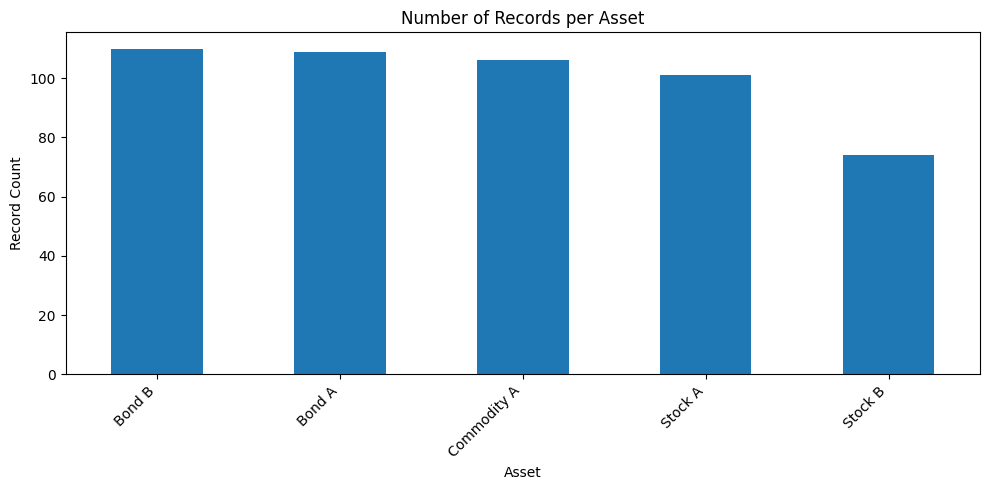

In [36]:
asset_record_counts = df["asset"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
asset_record_counts.plot(kind="bar")
plt.title("Number of Records per Asset")
plt.xlabel("Asset")
plt.ylabel("Record Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "records_per_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Price Distribution

This chart shows the overall distribution of asset prices.

It helps identify:

- Price spread
- Skewness
- Extreme values
- Possible anomalies

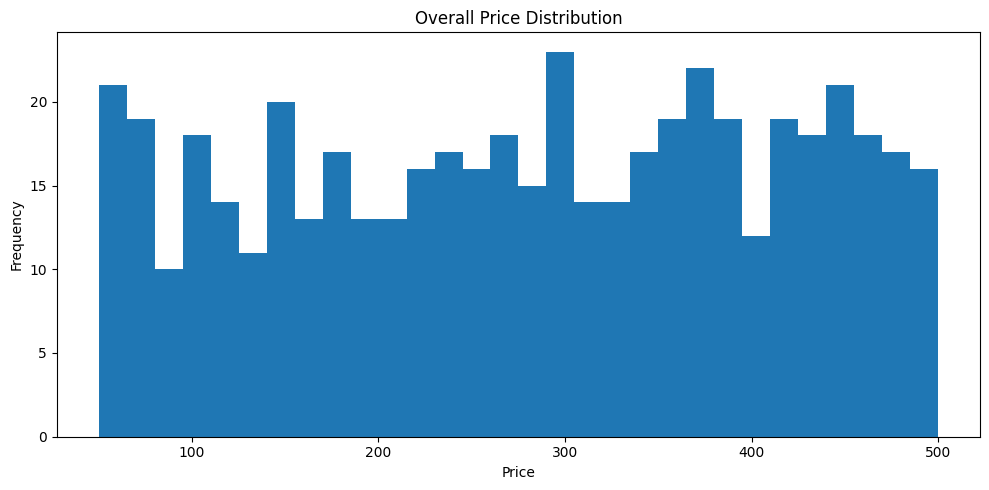

In [37]:
plt.figure(figsize=(10, 5))
plt.hist(df["price"].dropna(), bins=30)
plt.title("Overall Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Price Distribution by Asset

Different assets may have different price ranges.

A boxplot helps compare each asset's price distribution and spot possible outliers.

<Figure size 1200x600 with 0 Axes>

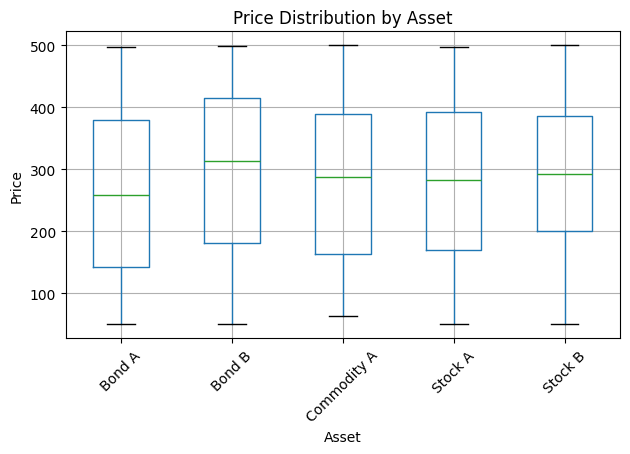

In [38]:
plt.figure(figsize=(12, 6))
df.boxplot(column="price", by="asset", rot=45)
plt.title("Price Distribution by Asset")
plt.suptitle("")
plt.xlabel("Asset")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_distribution_by_asset.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Price Trend Over Time

This section visualizes price movement over time for each asset.

This is important for time series forecasting because we need to understand:

- Trend direction
- Volatility
- Sudden jumps or drops
- Asset-specific behavior

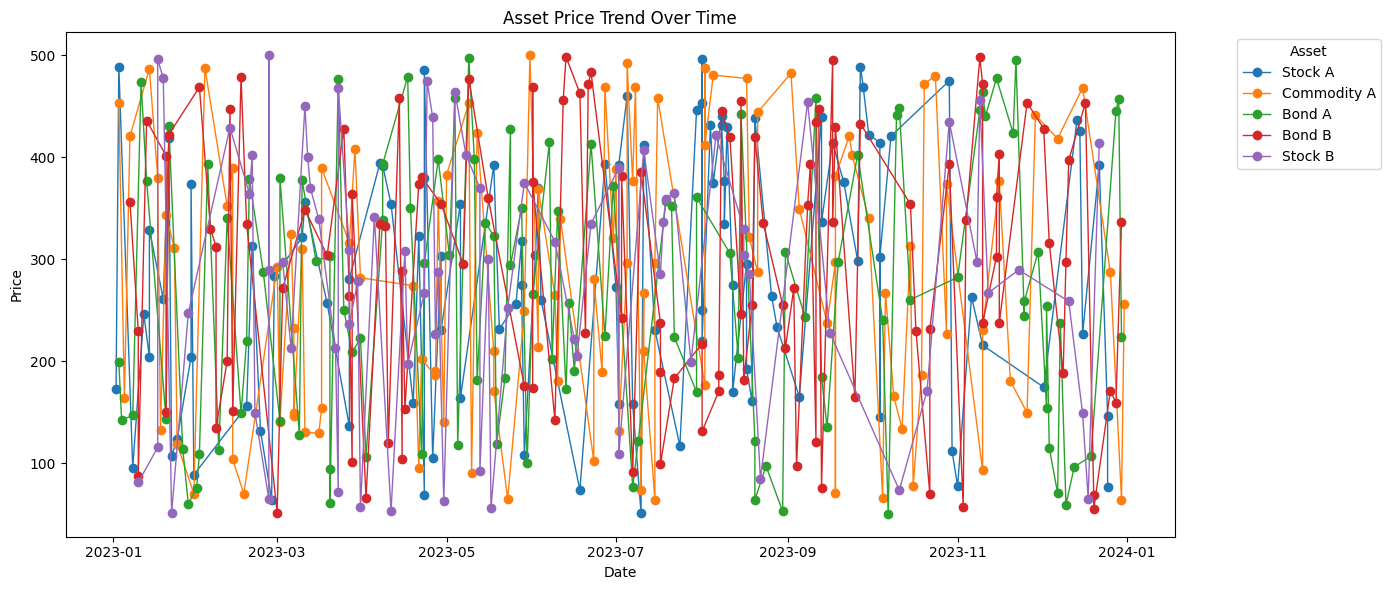

In [39]:
df_sorted = df.sort_values("date").copy()

plt.figure(figsize=(14, 6))

for asset in df_sorted["asset"].dropna().unique():
    asset_data = df_sorted[df_sorted["asset"] == asset]
    plt.plot(
        asset_data["date"],
        asset_data["price"],
        marker="o",
        linewidth=1,
        label=asset
    )

plt.title("Asset Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(title="Asset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "asset_price_trend_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Daily Average Price Trend

Since the dataset contains multiple assets, we calculate the average price per day.

This gives a high-level market or portfolio-like price trend.

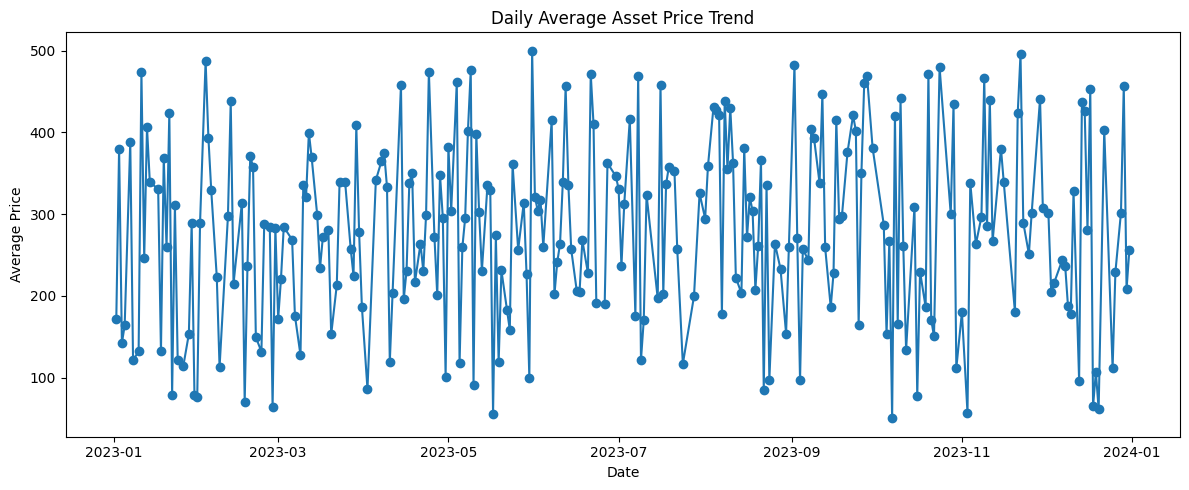

,date,average_price
0,2023-01-02,172.1500
1,2023-01-03,380.1367
2,2023-01-04,142.2400
3,2023-01-05,163.7700
4,2023-01-07,388.3800


In [40]:
daily_average_price = (
    df.groupby("date", as_index=False)
    .agg(average_price=("price", "mean"))
    .sort_values("date")
)

plt.figure(figsize=(12, 5))
plt.plot(
    daily_average_price["date"],
    daily_average_price["average_price"],
    marker="o"
)
plt.title("Daily Average Asset Price Trend")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "daily_average_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

daily_average_price.head()

## 18. Create Basic Time Features

Time-based features help machine learning models understand calendar patterns.

We create:

- Year
- Month
- Quarter
- Day
- Day of week
- Month start flag
- Month end flag

In [41]:
df_time = df.copy()

df_time["year"] = df_time["date"].dt.year
df_time["month"] = df_time["date"].dt.month
df_time["quarter"] = df_time["date"].dt.quarter
df_time["day"] = df_time["date"].dt.day
df_time["day_of_week"] = df_time["date"].dt.dayofweek
df_time["is_month_start"] = df_time["date"].dt.is_month_start.astype(int)
df_time["is_month_end"] = df_time["date"].dt.is_month_end.astype(int)

df_time.head()

,date,asset,price,year,month,quarter,day,day_of_week,is_month_start,is_month_end
0,2023-07-10,Bond B,385.6400,2023,7,3,10,0,0,0
1,2023-03-03,Stock B,297.2000,2023,3,1,3,4,0,0
2,2023-09-13,Bond B,75.9800,2023,9,3,13,2,0,0
3,2023-01-07,Bond B,356.3400,2023,1,1,7,5,0,0
4,2023-06-04,Stock A,260.0500,2023,6,2,4,6,0,0


## 19. Monthly Average Price

This analysis helps understand whether prices show monthly movement patterns.

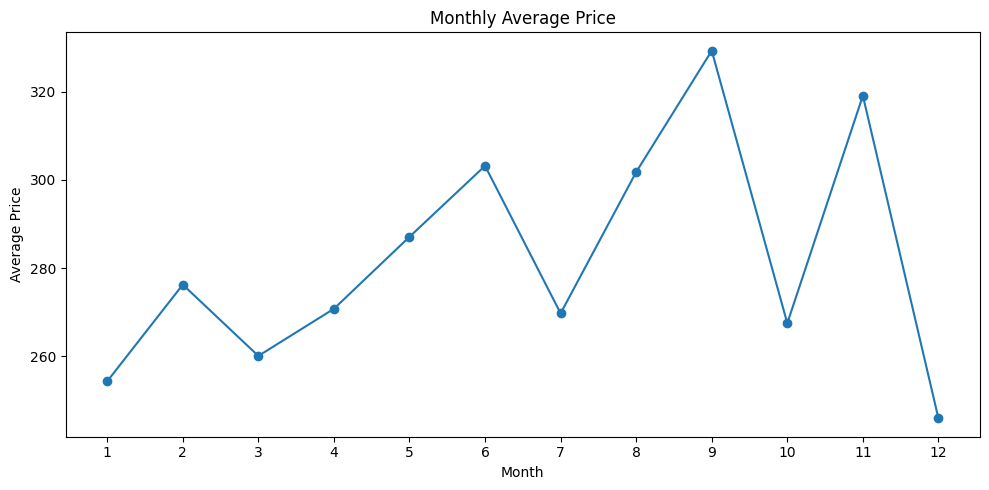

,month,average_price
0,1,254.3122
1,2,276.2244
2,3,260.0656
3,4,270.7538
4,5,287.0709
5,6,303.1674
6,7,269.7191
7,8,301.7533
8,9,329.2718
9,10,267.4793


In [42]:
monthly_price = (
    df_time.groupby("month", as_index=False)
    .agg(average_price=("price", "mean"))
    .sort_values("month")
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_price["month"], monthly_price["average_price"], marker="o")
plt.title("Monthly Average Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_average_price.png", dpi=300, bbox_inches="tight")
plt.show()

monthly_price

## 20. Simple Return Calculation

For financial time series, returns are often more useful than raw prices.

Here we calculate percentage change in price for each asset:

```text
daily_return = current_price / previous_price - 1

In [43]:
df_returns = df.sort_values(["asset", "date"]).copy()

df_returns["daily_return"] = (
    df_returns.groupby("asset")["price"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

df_returns["daily_return"] = df_returns["daily_return"].fillna(0)

df_returns.head(10)

,date,asset,price,daily_return
213,2023-01-03,Bond A,198.6100,0.0000
264,2023-01-04,Bond A,142.2400,-0.2838
101,2023-01-08,Bond A,146.5800,0.0305
136,2023-01-11,Bond A,473.2000,2.2283
20,2023-01-13,Bond A,376.5700,-0.2042
247,2023-01-20,Bond A,143.1900,-0.6198
395,2023-01-21,Bond A,430.6300,2.0074
484,2023-01-26,Bond A,113.9800,-0.7353
95,2023-01-28,Bond A,59.9100,-0.4744
366,2023-01-31,Bond A,75.9700,0.2681


## 22. Basic Outlier Detection Using IQR

Before building a formal anomaly detection model, we can use the IQR method to identify possible price outliers.

IQR method:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Rows outside this range are treated as possible outliers.

In [44]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of possible price outliers:", len(outliers))

outliers.head()

Q1: 169.945
Q3: 393.1325
IQR: 223.1875
Lower bound: -164.83625
Upper bound: 727.9137499999999
Number of possible price outliers: 0


,date,asset,price


## 23. Check Data Quality Issues

This section summarizes common data quality problems:

- Missing dates
- Missing asset names
- Missing prices
- Negative prices
- Duplicate rows
- Invalid date values

In [45]:
quality_report = {
    "total_rows": len(df),
    "total_columns": len(df.columns),
    "missing_date_count": int(df["date"].isna().sum()),
    "missing_asset_count": int(df["asset"].isna().sum()),
    "missing_price_count": int(df["price"].isna().sum()),
    "negative_price_count": int((df["price"] < 0).sum()),
    "duplicate_row_count": int(df.duplicated().sum()),
    "unique_asset_count": int(df["asset"].nunique()),
    "unique_date_count": int(df["date"].nunique()),
    "possible_outlier_count_iqr": int(len(outliers))
}

quality_report_df = pd.DataFrame([quality_report])

quality_report_df

,total_rows,total_columns,missing_date_count,missing_asset_count,missing_price_count,negative_price_count,duplicate_row_count,unique_asset_count,unique_date_count,possible_outlier_count_iqr
0,500,3,0,0,0,0,0,5,267,0


## 24. Save Data Understanding Outputs

We save useful summaries for future documentation and reporting:

- Asset summary
- Missing value summary
- Data quality report
- Daily average price summary

In [46]:
asset_summary.to_csv(TABLES_DIR / "asset_summary.csv", index=False)
missing_summary.to_csv(TABLES_DIR / "missing_value_summary.csv")
quality_report_df.to_csv(TABLES_DIR / "data_quality_report.csv", index=False)
daily_average_price.to_csv(TABLES_DIR / "daily_average_price.csv", index=False)

print("Saved reports:")
print(TABLES_DIR / "asset_summary.csv")
print(TABLES_DIR / "missing_value_summary.csv")
print(TABLES_DIR / "data_quality_report.csv")
print(TABLES_DIR / "daily_average_price.csv")

Saved reports:
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\asset_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\missing_value_summary.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\data_quality_report.csv
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\daily_average_price.csv


## 25. Key Observations


### Dataset Structure

- The dataset contains asset price records with date, asset name, and price.
- The main target variable for forecasting is `price`.
- The asset column can be used to compare price behavior across assets.

### Data Quality

- Missing values should be handled before modeling.
- Duplicate records should be removed if present.
- Negative prices are invalid and should be removed.
- Price outliers should be reviewed before anomaly detection.

### Time Series Suitability

- The date column allows time-based analysis.
- Data should be sorted by `asset` and `date` before creating lag and rolling features.
- Train-test split should be time-based, not random.

### Modeling Direction

- Forecasting target: `price`
- Anomaly detection feature: `price`
- Additional useful feature: `daily_return`